In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sklearn
import seaborn as sns

# Data Processing and Visualisation

In [24]:
#Load dataset
iris_data = pd.read_csv('Iris.csv')
iris_data.info()
iris_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


After loading the dataset, more info about the data is obtained from .info() and .head()
It shows that there is 150 entries with 5 columns (and 1 primary key ['Id'])

In [25]:
#Check for missing data 
'''Function taken from https://www.kaggle.com/code/agilesifaka/step-by-step-iris-ml-project#3.-Explore-data-with-visualization'''
def missing_value_describe(data):
    # check missing values in training data
    missing_value_stats = (data.isnull().sum() / len(data)*100)
    missing_value_col_count = sum(missing_value_stats > 0)
    missing_value_stats = missing_value_stats.sort_values(ascending=False)[:missing_value_col_count]
    print("Number of columns with missing values:", missing_value_col_count)
    if missing_value_col_count != 0:
        # print out column names with missing value percentage
        print("\nMissing percentage (desceding):")
        print(missing_value_stats)
    else:
        print("No missing data")
missing_value_describe(iris_data)

Number of columns with missing values: 0
No missing data


In [26]:
iris_data = iris_data.drop(['Id'], axis=1)
iris_data.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

The function is then used to check if there is any missing data in the entries (there aren't)
Since the Id is just a identifier/primary key, we can drop it to make a more 'streamlined' dataset

In [27]:
#We then check the distribution of each classes
print(iris_data.groupby('Species').size())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


In [29]:
iris_data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [36]:
iris_data = iris_data.dropna(subset=['Species'])

X = iris_data[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
Y = iris_data['Species']

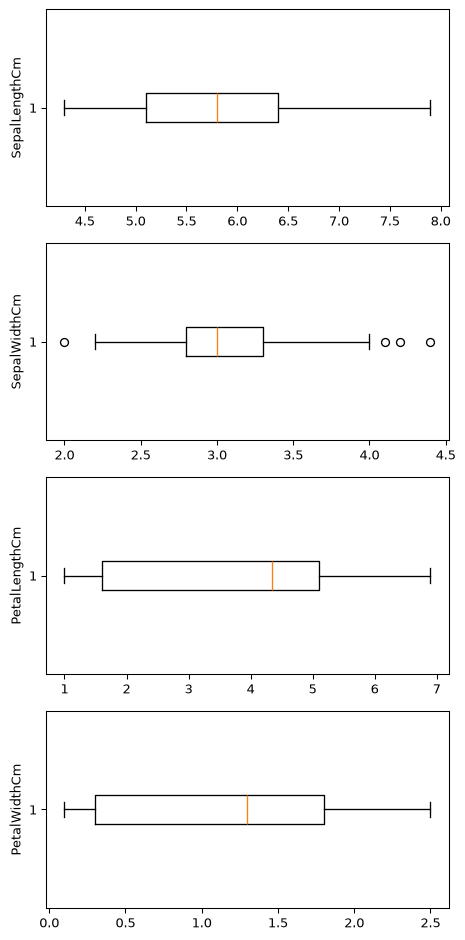

In [45]:
fig, ax = plt.subplots(len(X.columns), 1, figsize=(5, 10), dpi=95)
for i, col in enumerate(X.columns):
    ax[i].boxplot(X[col], orientation='horizontal')
    ax[i].set_ylabel(col)
plt.tight_layout()
plt.show()

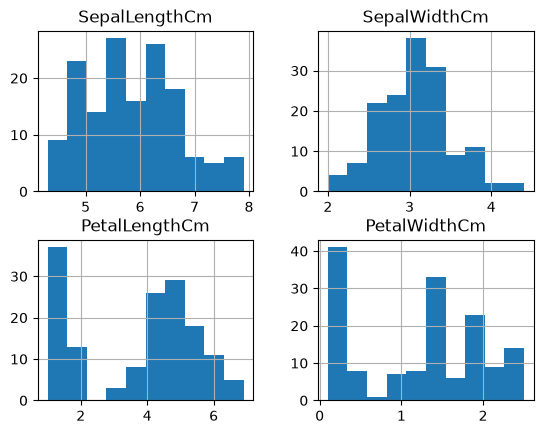

In [42]:
iris_data.hist()
plt.show()

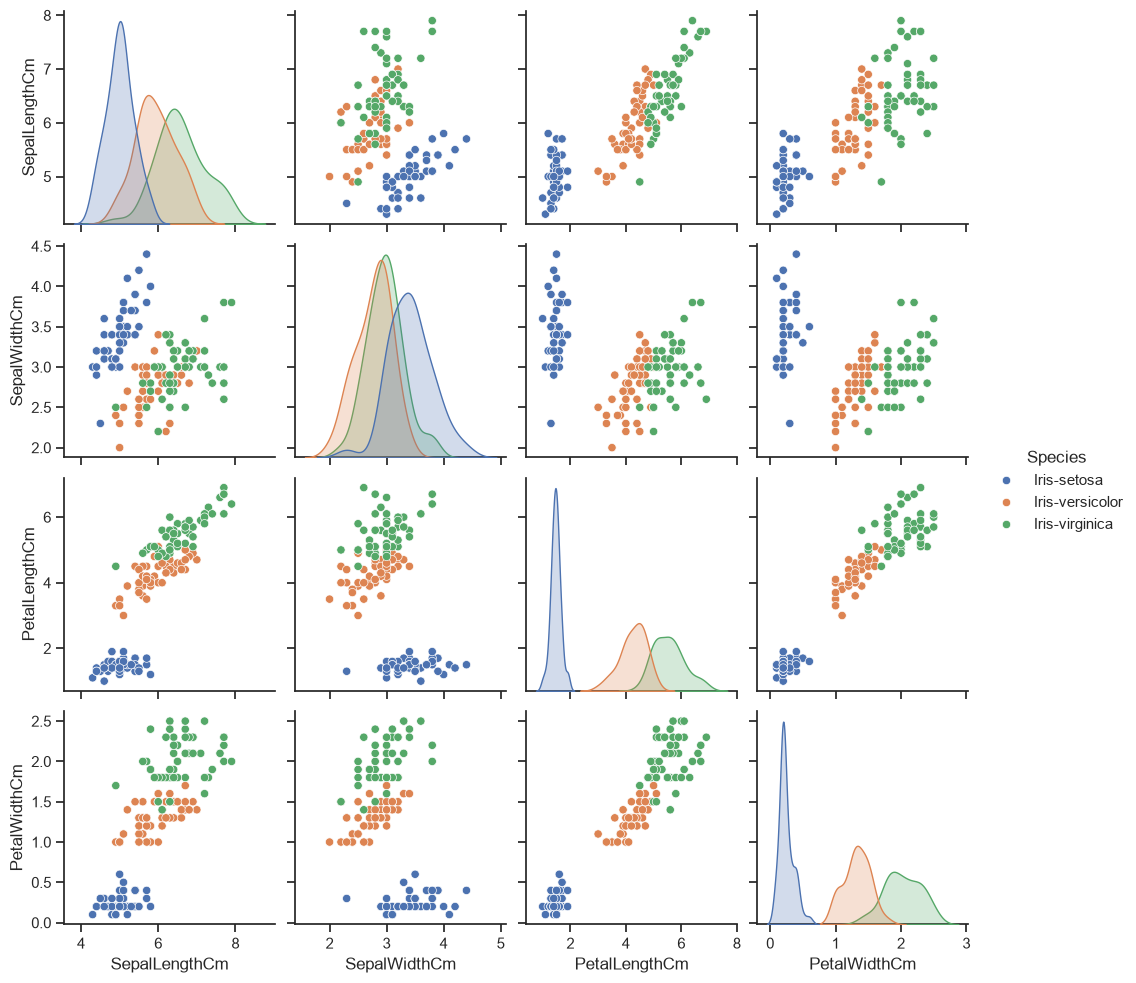

In [48]:
sns.set(style="ticks")
sns.pairplot(iris_data, hue="Species")

The data is then visualised using a boxplot (box and whiskers plot), histogram, and multivariate plot. 
It can be seen from the hisogram that Sepal Length and Width are normal distributions
From the scatter plot, it can be seen that Petal Width and Lengths have the strongest relationship pair-wise.

# Data Modeling